### Código de asignación de material para simulación FEM

El siguiente *notebook* presenta un código para la asignación de material a partir de la lectura de una imagen binaria.

<div class="alert alert-block alert-warning">
<b> Nota importante:</b> Es posible que se requiera revisar que el orden de lectura-asignación de material coincida con la orientación correcta de la imagen. Se colocará un comentario alertando sobre dónde se requiere revisar este cambio a la hora de implementar este código en la solución.
</div>

In [55]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

---

#### Generación de imagenes binarias

In [56]:
# Generar imágenes binarias
#def generate_random_image(size=(64, 64)):
#    return np.random.choice([0, 1], size, p=[0.5, 0.5]).astype(np.uint8)

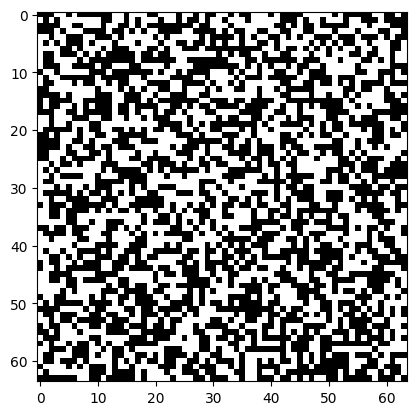

In [57]:
# Generar una imagen para pruebas
#size = 64 
#img = generate_random_image((size,size)) 
imgenes = np.load("../Generacion de imagenes/images0_125.npz")
images = imgenes["arr_0"]
img = images[0]
# Plotear la imagen
fig_im, ax_im = plt.subplots()
plt.imshow(img,cmap="gray_r")

In [58]:
img

array([[1, 1, 1, ..., 1, 0, 1],
       [0, 1, 0, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 0, 0, ..., 1, 1, 0],
       [0, 1, 0, ..., 1, 1, 0],
       [1, 1, 1, ..., 1, 0, 1]], dtype=uint8)

#### Generación de la geometría para FEM

In [59]:
len_cell = 1 # Longitud del lado de la celda unitaria, a
len_mesh = np.shape(img)[0] + 1

X, Y = np.meshgrid( np.linspace(0, len_cell, len_mesh), np.linspace(0, len_cell, len_mesh) )
X_flat = X.flatten()
Y_flat = Y.flatten()
coords_raw = np.stack((X_flat, Y_flat), axis=1)

In [60]:
coords_raw # Coordenadas

array([[0.      , 0.      ],
       [0.015625, 0.      ],
       [0.03125 , 0.      ],
       ...,
       [0.96875 , 1.      ],
       [0.984375, 1.      ],
       [1.      , 1.      ]])

In [61]:
nodal_id = np.array(range(len(coords_raw)))
bc_flag_matrix = np.zeros((len(coords_raw), 2))

In [62]:
coords_array = np.column_stack((nodal_id, coords_raw, bc_flag_matrix))
coords_array

array([[0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00],
       [1.00000e+00, 1.56250e-02, 0.00000e+00, 0.00000e+00, 0.00000e+00],
       [2.00000e+00, 3.12500e-02, 0.00000e+00, 0.00000e+00, 0.00000e+00],
       ...,
       [4.22200e+03, 9.68750e-01, 1.00000e+00, 0.00000e+00, 0.00000e+00],
       [4.22300e+03, 9.84375e-01, 1.00000e+00, 0.00000e+00, 0.00000e+00],
       [4.22400e+03, 1.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00]])

In [63]:
# Guardar el archivo nodes.txt con el formato de la documentación de SolidsPy
nodes_filepath = "./fem/nodes.txt"
np.savetxt(nodes_filepath, coords_array)

#### Generación de la topología para FEM

In [64]:
neles_side = np.shape(img)[0]
ncoords_side = len_mesh

eles_raw = np.empty((0,4),dtype=int)

for j in np.arange(0, neles_side):
    for i in np.arange(0, neles_side):
        # Nodos de cada elemento
        n0 = j * ncoords_side + i         # inferior-izquierdo
        n1 = n0 + 1                      # inferior-derecho
        n2 = n1 + ncoords_side           # superior-derecho
        n3 = n0 + ncoords_side           # superior-izquierdo
        
        eles_raw = np.vstack( (eles_raw, [n0, n1, n2, n3]) )

In [65]:
eles_raw

array([[   0,    1,   66,   65],
       [   1,    2,   67,   66],
       [   2,    3,   68,   67],
       ...,
       [4156, 4157, 4222, 4221],
       [4157, 4158, 4223, 4222],
       [4158, 4159, 4224, 4223]])

<div class="alert alert-block alert-warning">
<b>Importante:</b> En caso de requerir invertir el orden de asignación de las imágenes debe cambiarse la siguiente celda.
</div>

In [66]:
img_assign = np.flip(img,axis=0).flatten() # Invertir el orden de la imagen y convertir en un vector
img_assign

array([1, 1, 1, ..., 1, 0, 1], dtype=uint8)

In [67]:
eles_id = np.array(range(len(eles_raw)))
eles_type = np.ones(len(eles_raw))

In [68]:
eles_array = np.column_stack((eles_id, eles_type, img_assign, eles_raw))
eles_array

array([[0.000e+00, 1.000e+00, 1.000e+00, ..., 1.000e+00, 6.600e+01,
        6.500e+01],
       [1.000e+00, 1.000e+00, 1.000e+00, ..., 2.000e+00, 6.700e+01,
        6.600e+01],
       [2.000e+00, 1.000e+00, 1.000e+00, ..., 3.000e+00, 6.800e+01,
        6.700e+01],
       ...,
       [4.093e+03, 1.000e+00, 1.000e+00, ..., 4.157e+03, 4.222e+03,
        4.221e+03],
       [4.094e+03, 1.000e+00, 0.000e+00, ..., 4.158e+03, 4.223e+03,
        4.222e+03],
       [4.095e+03, 1.000e+00, 1.000e+00, ..., 4.159e+03, 4.224e+03,
        4.223e+03]])

In [69]:
# Guardar el archivo nodes.txt con el formato de la documentación de SolidsPy
elements_filepath = "./fem/eles.txt"
np.savetxt(elements_filepath, eles_array, fmt="%d")

#### Dibujar la asignación de material y la celda unitaria
Este es un paso de verificación de las celdas anteriores.

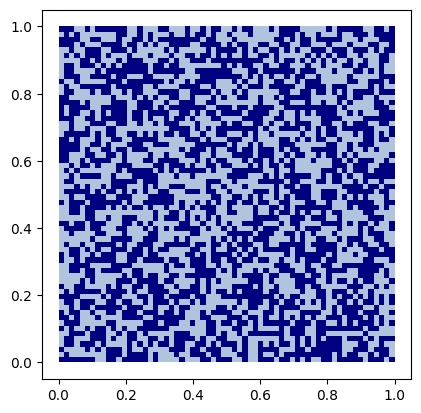

In [70]:
fig, ax = plt.subplots()

ele_id_cont = 0
for ele_topo in eles_raw:
    
    x = coords_raw[ele_topo][:,0]
    y = coords_raw[ele_topo][:,1]

    if img_assign[ele_id_cont] == 1:
        mat_color = "navy"
    elif img_assign[ele_id_cont] == 0:
        mat_color = "lightsteelblue"
    else:
        mat_color = "black"
    
    ele_id_cont += 1
    ax.fill(x, y, facecolor = mat_color)

ax.set_aspect('equal','box')
plt.show()


#### Creación del archivo de material


In [71]:
# Módulo Elástico [Pa] y Coeficiente de Poisson

mat1 = [831e6, 0.35] # Cancellous bone
mat2 = [12e9, 0.27] # Calcium Phosphates

mater_array = np.vstack((mat1,mat2))

In [ ]:
material_filepath = "./fem/mater.txt"
np.savetxt(material_filepath, mater_array)

: 